In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r'D:\Depi\Data\Sample - Superstore 2019 (1).xls')

In [3]:
df.isnull().sum()

Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [ ]:
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].median())

In [5]:
df.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [5]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


In [11]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Profit Margin', 'Shipping Duration',
       'Sales Performance Category', 'Year', 'Month', 'Month Name', 'Day',
       'Day Name'],
      dtype='str')

In [ ]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100  
df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Sales Performance Category'] = np.where(df['Sales'] >= 2000 , 'Very High', np.where(df['Sales'] >= 1000, 'High', np.where(df['Sales'] >= 500 ,'Medium' , 'Low')))
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Day'] = df['Order Date'].dt.day
df['Day Name'] = df['Order Date'].dt.day_name()

In [12]:
df[['Sales' , 'Profit' , 'Quantity']].corr()

,Sales,Profit,Quantity
Sales,1.000000,0.479064,0.200795
Profit,0.479064,1.000000,0.066253
Quantity,0.200795,0.066253,1.000000


Text(0.5, 1.0, 'Montly_Sales')

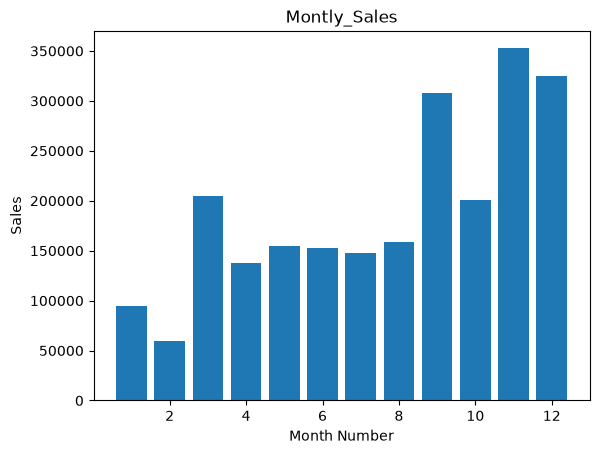

In [13]:
Montly_Sales = df.groupby('Month')['Sales'].sum().reset_index()
plt.bar(Montly_Sales['Month'],Montly_Sales['Sales'])
plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.title('Montly_Sales')

Text(0.5, 1.0, 'Montly_Quantity')

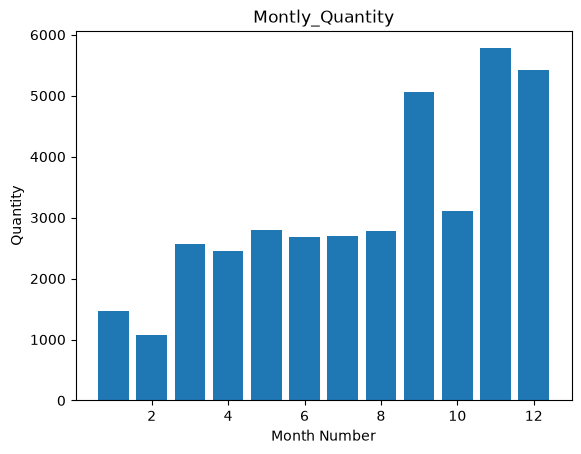

In [14]:
Montly_Quantity = df.groupby('Month')['Quantity'].sum().reset_index()
plt.bar(Montly_Quantity['Month'],Montly_Quantity['Quantity'])
plt.xlabel('Month Number')
plt.ylabel('Quantity')
plt.title('Montly_Quantity')

Text(0.5, 1.0, 'Montly_Profit')

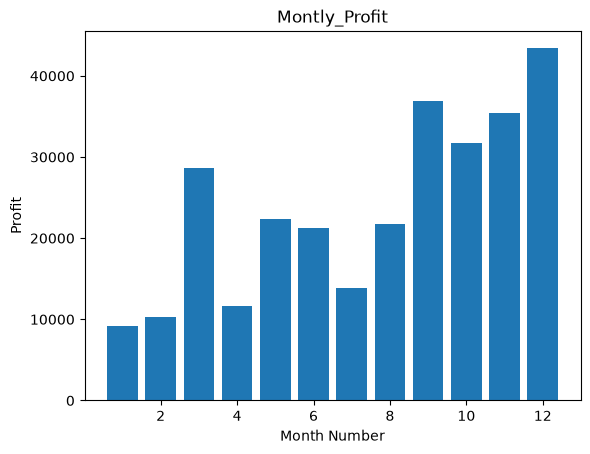

In [15]:
Montly_Profit = df.groupby('Month')['Profit'].sum().reset_index()
plt.bar(Montly_Profit['Month'],Montly_Profit['Profit'])
plt.xlabel('Month Number')
plt.ylabel('Profit')
plt.title('Montly_Profit')

In [16]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Profit Margin', 'Shipping Duration',
       'Sales Performance Category', 'Year', 'Month', 'Month Name', 'Day',
       'Day Name'],
      dtype='str')

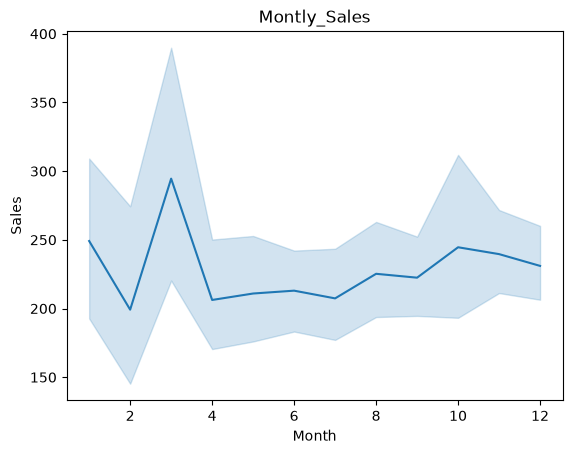

In [17]:
sns.lineplot(data=df,x='Month',y='Sales',markers='o')
plt.title('Montly_Sales')
plt.show()

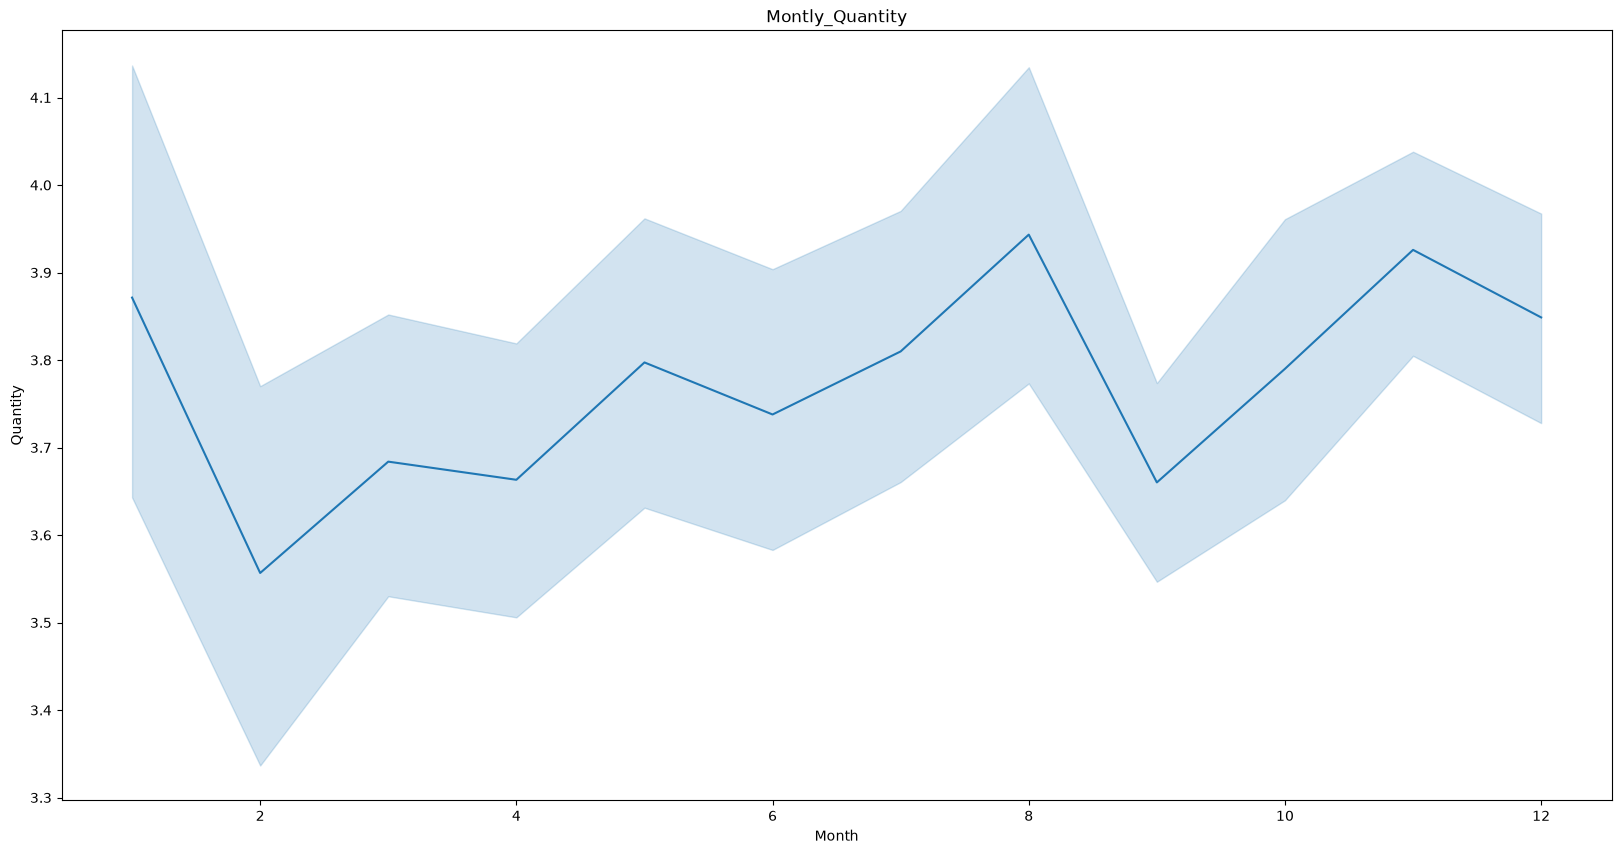

In [18]:
plt.figure(figsize=(20,10))
sns.lineplot(data=df,x='Month',y='Quantity',markers='o')
plt.title('Montly_Quantity')
plt.show()

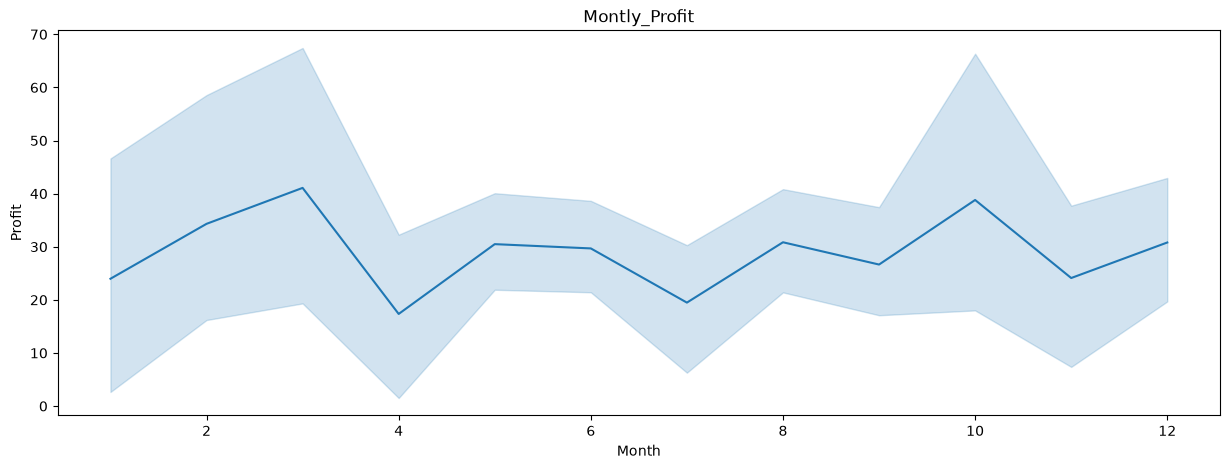

In [19]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df,x='Month',y='Profit',markers='o')
plt.title('Montly_Profit')
plt.show()

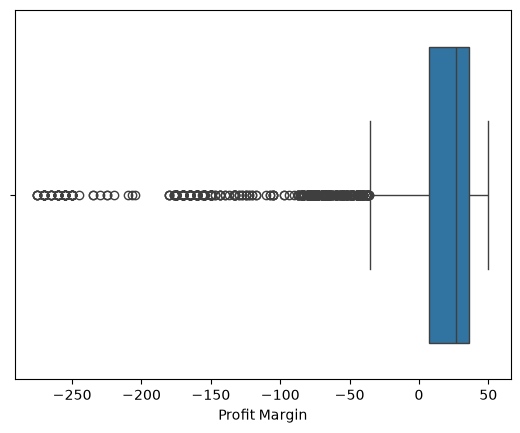

In [21]:
sns.boxplot(data=df,x='Profit Margin')
plt.show()

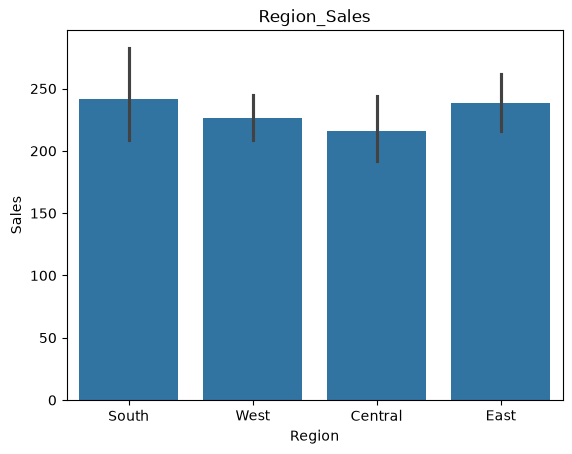

In [22]:
sns.barplot(data=df,x='Region',y='Sales')
plt.title('Region_Sales')
plt.show()

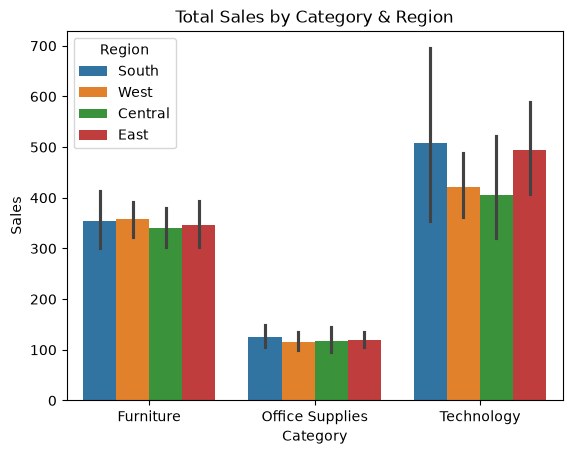

In [25]:
sns.barplot(data=df,x='Category',y='Sales',hue='Region')
plt.title('Total Sales by Category & Region')
plt.show()

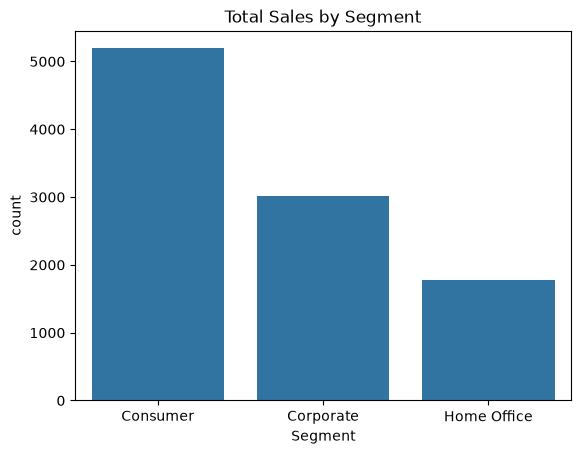

In [26]:
sns.countplot(data=df,x='Segment')
plt.title('Total Sales by Segment')
plt.show()

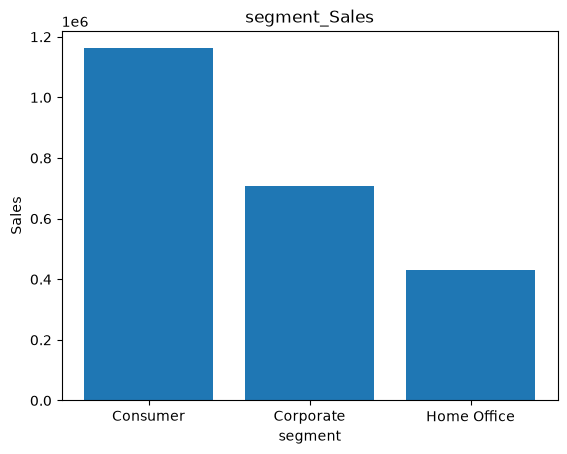

In [28]:
segment = df.groupby('Segment')['Sales'].sum().reset_index()
plt.bar(segment['Segment'],segment['Sales'])
plt.xlabel('segment')
plt.ylabel('Sales')
plt.title('segment_Sales')
plt.show()

In [7]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 15  Sub-Category   